In [1]:
!pip install -q mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.7 MB/s eta 0:00:00


In [1]:
import mediapipe as mp

print(mp.__version__)
print(dir(mp))

0.10.35
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [2]:
!pip install -q kaggle

In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_dd900fec06fe1e63c14ed6cfa2ef8776"

In [4]:
!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
100% 634M/634M [00:03<00:00, 221MB/s]



In [5]:
!unzip -q /content/hands-and-palm-images-dataset.zip -d /content/palm_dataset

In [6]:
folder = "/content/palm_dataset/Hands/Hands"

files = os.listdir(folder)

print("Total Images:", len(files))

Total Images: 11076


In [9]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

Create the Hand Landmarker

In [11]:
base_options = python.BaseOptions(
    model_asset_path="hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

detector = vision.HandLandmarker.create_from_options(options)

Test on One Image

In [12]:
folder = "/content/palm_dataset/Hands/Hands"

files = os.listdir(folder)

image_path = os.path.join(folder, files[0])

mp_image = mp.Image.create_from_file(image_path)

result = detector.detect(mp_image)

print("Hands detected:", len(result.hand_landmarks))

Hands detected: 1


Draw Landmarks

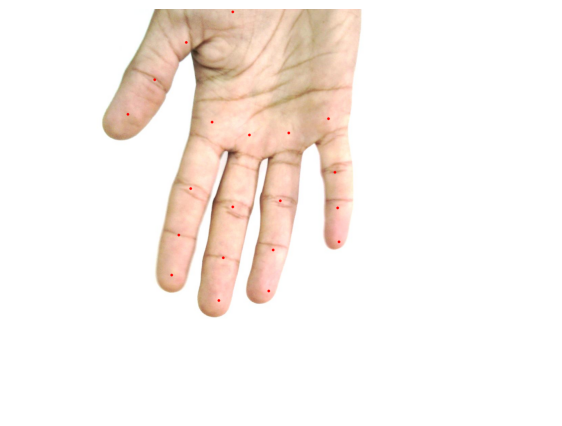

In [13]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

for hand in result.hand_landmarks:

    for point in hand:

        x = int(point.x * w)
        y = int(point.y * h)

        cv2.circle(image, (x, y), 4, (255,0,0), -1)

plt.figure(figsize=(7,7))
plt.imshow(image)
plt.axis("off")
plt.show()

Detect Hands in 100 Images

In [14]:
detected = 0

for file in files[:100]:

    path = os.path.join(folder, file)

    mp_image = mp.Image.create_from_file(path)

    result = detector.detect(mp_image)

    if len(result.hand_landmarks) > 0:
        detected += 1

print("Images:",100)
print("Detected:",detected)
print("Detection Rate:",detected)

Images: 100
Detected: 96
Detection Rate: 96


Count Hands Per Image

In [15]:
hand_counts = []

for file in files[:500]:

    path = os.path.join(folder,file)

    mp_image = mp.Image.create_from_file(path)

    result = detector.detect(mp_image)

    hand_counts.append(len(result.hand_landmarks))

Plot Distribution

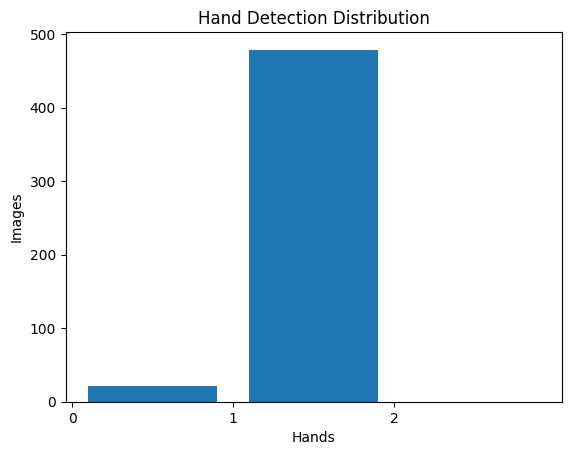

In [16]:
plt.hist(hand_counts,bins=[0,1,2,3],rwidth=0.8)

plt.xticks([0,1,2])

plt.xlabel("Hands")

plt.ylabel("Images")

plt.title("Hand Detection Distribution")

plt.show()

Extract 21 Landmarks

In [17]:
path = os.path.join(folder, files[0])

mp_image = mp.Image.create_from_file(path)

result = detector.detect(mp_image)

landmarks = []

for lm in result.hand_landmarks[0]:

    landmarks.append([lm.x,lm.y,lm.z])

landmarks = np.array(landmarks)

print(landmarks.shape)

(21, 3)


Create a Landmark DataFrame

In [19]:
import pandas as pd

rows = []

for file in files[:500]:

    path = os.path.join(folder,file)

    mp_image = mp.Image.create_from_file(path)

    result = detector.detect(mp_image)

    if len(result.hand_landmarks)==0:
        continue

    row=[]

    for lm in result.hand_landmarks[0]:
        row.extend([lm.x,lm.y,lm.z])

    rows.append(row)

columns=[]

for i in range(21):
    columns.extend([f"x{i}",f"y{i}",f"z{i}"])

df=pd.DataFrame(rows,columns=columns)

df.head()

,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,0.523848,-0.016068,7.750638e-07,0.410455,0.007448,-0.063429,0.324921,0.081809,-0.096428,0.266385,...,-0.095937,0.598148,0.401475,-0.142651,0.603708,0.489038,-0.168787,0.606069,0.572439,-0.185965
1,0.613403,0.142885,6.479034e-07,0.485582,0.179637,-0.029321,0.414147,0.287099,-0.041125,0.368728,...,-0.046598,0.689159,0.567755,-0.082764,0.696149,0.655958,-0.108740,0.695832,0.735409,-0.125186
2,0.589756,0.176784,7.336785e-08,0.651593,0.322843,-0.035615,0.653912,0.481225,-0.047672,0.615028,...,-0.034500,0.339796,0.570672,-0.050173,0.317445,0.649385,-0.059353,0.302641,0.718962,-0.065968
3,0.618125,0.033679,1.066622e-07,0.715312,0.146429,-0.039647,0.747889,0.301633,-0.047334,0.732523,...,-0.010326,0.438436,0.470978,-0.022090,0.430306,0.541098,-0.030974,0.422343,0.606518,-0.040249
4,0.749775,0.077233,9.731627e-07,0.627607,0.088168,-0.017134,0.544206,0.183127,-0.033710,0.477164,...,-0.091895,0.797528,0.517333,-0.128710,0.787823,0.614828,-0.145386,0.777043,0.698857,-0.152625


Dataset Summary

In [20]:
import os

folder = "/content/palm_dataset/Hands/Hands"

files = os.listdir(folder)

print("="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Dataset Path      : {folder}")
print(f"Total Images      : {len(files)}")
print(f"Image Extensions  : {set([f.split('.')[-1] for f in files])}")

DATASET SUMMARY
Dataset Path      : /content/palm_dataset/Hands/Hands
Total Images      : 11076
Image Extensions  : {'jpg'}


Final EDA Report

In [22]:
print("="*60)
print("PALMISTRY DATASET EDA REPORT")
print("="*60)

print(f"Total Images                : {len(files)}")
print(f"Average Width               : {np.mean(widths):.2f}")
print(f"Average Height              : {np.mean(heights):.2f}")
print(f"Hand Detection Success      : {detected}/{len(hand_counts)}")
print(f"Average Hands per Image     : {np.mean(hand_counts):.2f}")
print(f"Landmark Features           : {df.shape[1]}")
print(f"Landmark Samples            : {df.shape[0]}")
print(f"Missing Values              : {df.isnull().sum().sum()}")

PALMISTRY DATASET EDA REPORT
Total Images                : 11076
Average Width               : 1600.00
Average Height              : 1200.00
Hand Detection Success      : 96/500
Average Hands per Image     : 0.96
Landmark Features           : 63
Landmark Samples            : 479
Missing Values              : 0
